In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path

BASE_DIR = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test-single-3")

experiments = {
    'test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=1000}-{mig_mode=async}': 'FlexiServe-Fast',
    'test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=1000}-{mig_mode=sync}': 'Stop-and-go',
    'test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}': 'FlexiServe-stable',
    'test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{fixed_blocks=5475}': 'Resize-Disable',
}

data = {}
for folder, name in experiments.items():
    csv_path = BASE_DIR / folder / "request_metrics.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df['experiment'] = name
        data[name] = df
        print(f"Loaded {name}: {len(df)} requests")
    else:
        print(f"Warning: {csv_path} not found")

Loaded FlexiServe-Fast: 200 requests
Loaded Stop-and-go: 200 requests
Loaded FlexiServe-stable: 200 requests
Loaded Resize-Disable: 200 requests


In [38]:
import re

def get_tokens_per_request(folder):
    """Read input+output tokens per request from benchmark_config.json."""
    with open(BASE_DIR / folder / "benchmark_config.json") as f:
        cfg = json.load(f)
    input_len, output_len = cfg.get("input_output_lens", [[0, 0]])[0]
    return input_len, output_len

def get_migration_time(folder):
    """Parse migration time(s) from server.log.
    - async: reads 'migration process time taken: Xs' (total background time)
    - sync:  sums all '[sync_migration]: updated cur_pp_layer_config ..., time taken: Xs'
             (each is the blocking downtime for one migration step)
    Returns list of migration times in seconds.
    """
    log_path = BASE_DIR / folder / "server.log"
    times = []
    with open(log_path) as f:
        for line in f:
            # async total migration time
            m = re.search(r'migration process time taken:\s*([\d.]+)s', line)
            if m:
                times.append(float(m.group(1)))
                continue
            # sync per-step downtime
            m = re.search(r'\[sync_migration\].*time taken:\s*([\d.]+)s', line)
            if m:
                times.append(float(m.group(1)))
    return times

# Order: baselines first, then FlexiServe variants
exp_order = ['Stop-and-go', 'Resize-Disable', 'FlexiServe-Fast', 'FlexiServe-stable']
folder_map = {v: k for k, v in experiments.items()}

summary_stats = []
for name in exp_order:
    if name not in data:
        continue
    df = data[name]
    # Correct duration: from first request start to last request finish
    total_time = (df['timestamp'] + df['e2els']).max() - df['timestamp'].min()
    input_len, output_len = get_tokens_per_request(folder_map[name])
    total_tokens = len(df) * (input_len + output_len)

    mig_times = get_migration_time(folder_map[name])
    mig_time_str = ' + '.join(f'{t:.1f}s' for t in mig_times) if mig_times else 'N/A'

    summary_stats.append({
        'Experiment': name,
        'Avg TTFT (ms)': df['ttfts'].mean() * 1000,
        'Avg TPOT (ms)': df['tpots'].mean() * 1000,
        'P50 TTFT (ms)': df['ttfts'].median() * 1000,
        'P50 TPOT (ms)': df['tpots'].median() * 1000,
        'P99 TTFT (ms)': df['ttfts'].quantile(0.99) * 1000,
        'P99 TPOT (ms)': df['tpots'].quantile(0.99) * 1000,
        'Throughput (tokens/s)': total_tokens / total_time if total_time > 0 else 0,
        'Migration Time': mig_time_str,
        'Num Requests': len(df),
    })

summary_df = pd.DataFrame(summary_stats)
summary_df


,Experiment,Avg TTFT (ms),Avg TPOT (ms),P50 TTFT (ms),P50 TPOT (ms),P99 TTFT (ms),P99 TPOT (ms),Throughput (tokens/s),Migration Time,Num Requests
0,Stop-and-go,6269.817902,1254.520118,7646.052066,1290.116655,16611.950162,1455.359951,601.795270,14.7s,200
1,Resize-Disable,11099.476554,731.540610,745.744118,829.825663,68754.785007,932.383985,817.467415,15.4s,200
2,FlexiServe-Fast,1878.446413,1085.338157,1067.932581,1136.416608,7732.053966,1240.737277,679.139137,19.8s,200
3,FlexiServe-stable,2272.510188,963.034536,692.126791,1011.755986,10097.276186,1125.952500,728.100178,22.5s,200


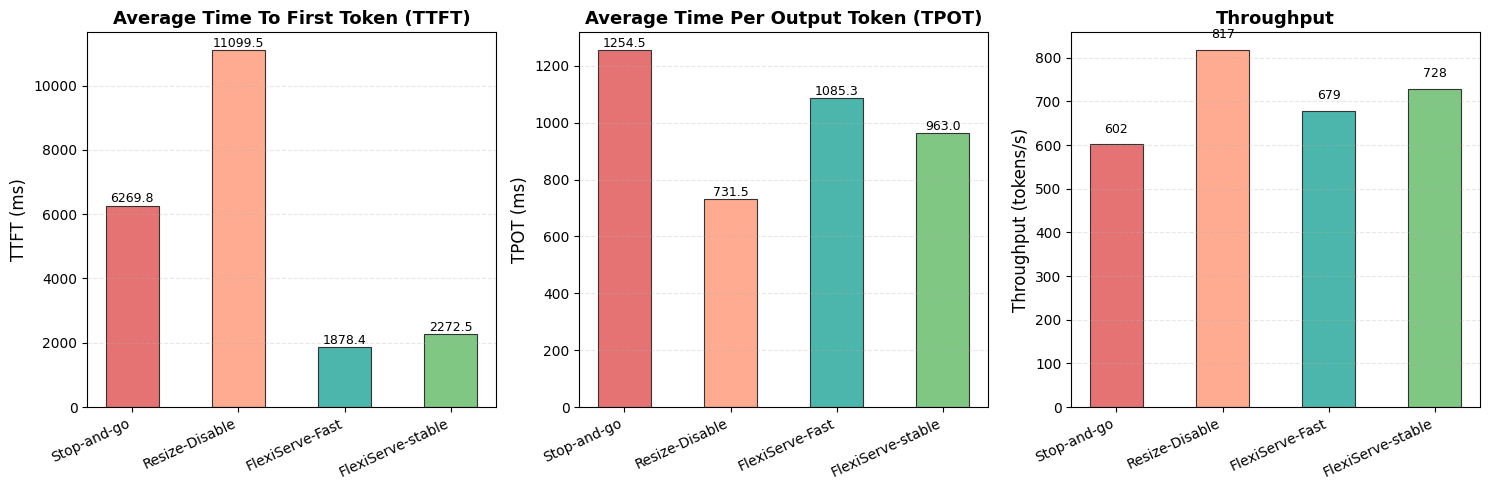

In [39]:
# Bar chart comparison of TTFT, TPOT, and Throughput
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

exp_names = summary_df['Experiment'].tolist()
# Harmonious color palette: warm tones for baselines, cool tones for FlexiServe
colors = ['#E57373', '#FFAB91', '#4DB6AC', '#81C784']  # Soft red, coral, teal, green

bar_width = 0.5  # Thinner bars

# TTFT comparison
ax1 = axes[0]
x = np.arange(len(exp_names))
bars1 = ax1.bar(x, summary_df['Avg TTFT (ms)'], width=bar_width, color=colors, edgecolor='#333', linewidth=0.8)
ax1.set_ylabel('TTFT (ms)', fontsize=12)
ax1.set_title('Average Time To First Token (TTFT)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(exp_names, rotation=25, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars1, summary_df['Avg TTFT (ms)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# TPOT comparison
ax2 = axes[1]
bars2 = ax2.bar(x, summary_df['Avg TPOT (ms)'], width=bar_width, color=colors, edgecolor='#333', linewidth=0.8)
ax2.set_ylabel('TPOT (ms)', fontsize=12)
ax2.set_title('Average Time Per Output Token (TPOT)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(exp_names, rotation=25, ha='right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars2, summary_df['Avg TPOT (ms)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9)

# Throughput comparison
ax3 = axes[2]
bars3 = ax3.bar(x, summary_df['Throughput (tokens/s)'], width=bar_width, color=colors, edgecolor='#333', linewidth=0.8)
ax3.set_ylabel('Throughput (tokens/s)', fontsize=12)
ax3.set_title('Throughput', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(exp_names, rotation=25, ha='right', fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars3, summary_df['Throughput (tokens/s)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:.0f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/e2e_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

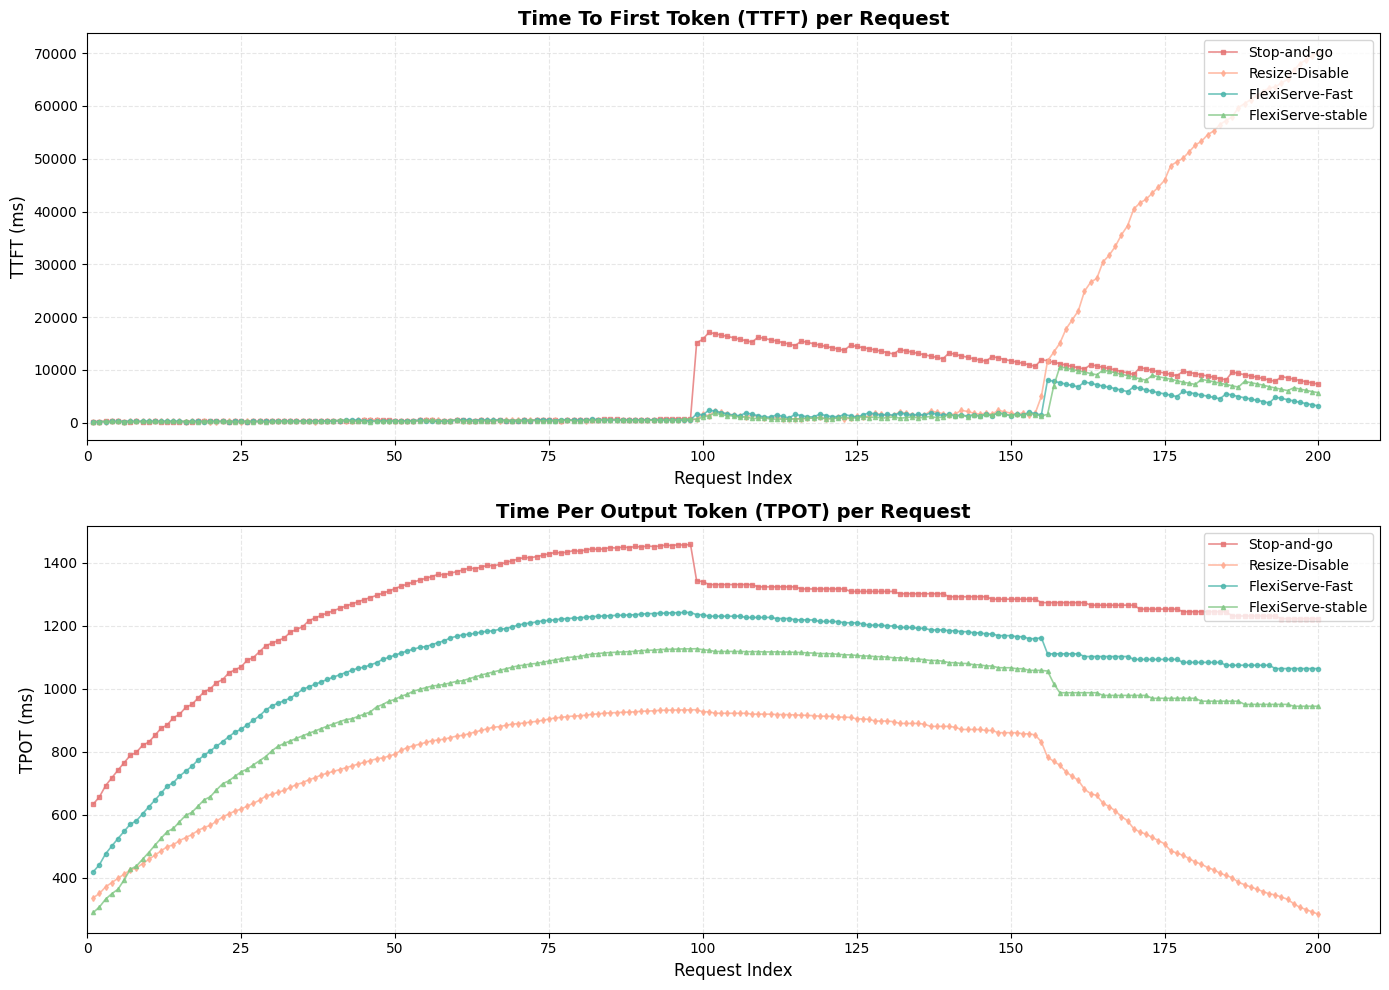

In [40]:
# Line chart: Per-request TTFT and TPOT
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Harmonious colors matching bar chart
colors = {'Stop-and-go': '#E57373', 'Resize-Disable': '#FFAB91',
          'FlexiServe-Fast': '#4DB6AC', 'FlexiServe-stable': '#81C784'}
markers = {'Stop-and-go': 's', 'Resize-Disable': 'd',
           'FlexiServe-Fast': 'o', 'FlexiServe-stable': '^'}

# Plot order: baselines first, then FlexiServe variants
plot_order = ['Stop-and-go', 'Resize-Disable', 'FlexiServe-Fast', 'FlexiServe-stable']

# TTFT per request
ax1 = axes[0]
for name in plot_order:
    if name in data:
        df = data[name].copy()
        df = df.sort_values('timestamp').reset_index(drop=True)
        df['request_idx'] = range(1, len(df) + 1)
        ax1.plot(df['request_idx'], df['ttfts'] * 1000, 
                 color=colors[name], marker=markers[name], markersize=3, 
                 linewidth=1.2, alpha=0.8, label=name)

ax1.set_xlabel('Request Index', fontsize=12)
ax1.set_ylabel('TTFT (ms)', fontsize=12)
ax1.set_title('Time To First Token (TTFT) per Request', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 210)

# TPOT per request
ax2 = axes[1]
for name in plot_order:
    if name in data:
        df = data[name].copy()
        df = df.sort_values('timestamp').reset_index(drop=True)
        df['request_idx'] = range(1, len(df) + 1)
        ax2.plot(df['request_idx'], df['tpots'] * 1000, 
                 color=colors[name], marker=markers[name], markersize=3, 
                 linewidth=1.2, alpha=0.8, label=name)

ax2.set_xlabel('Request Index', fontsize=12)
ax2.set_ylabel('TPOT (ms)', fontsize=12)
ax2.set_title('Time Per Output Token (TPOT) per Request', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, 210)

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/e2e_per_request_lines.png', dpi=150, bbox_inches='tight')
plt.show()

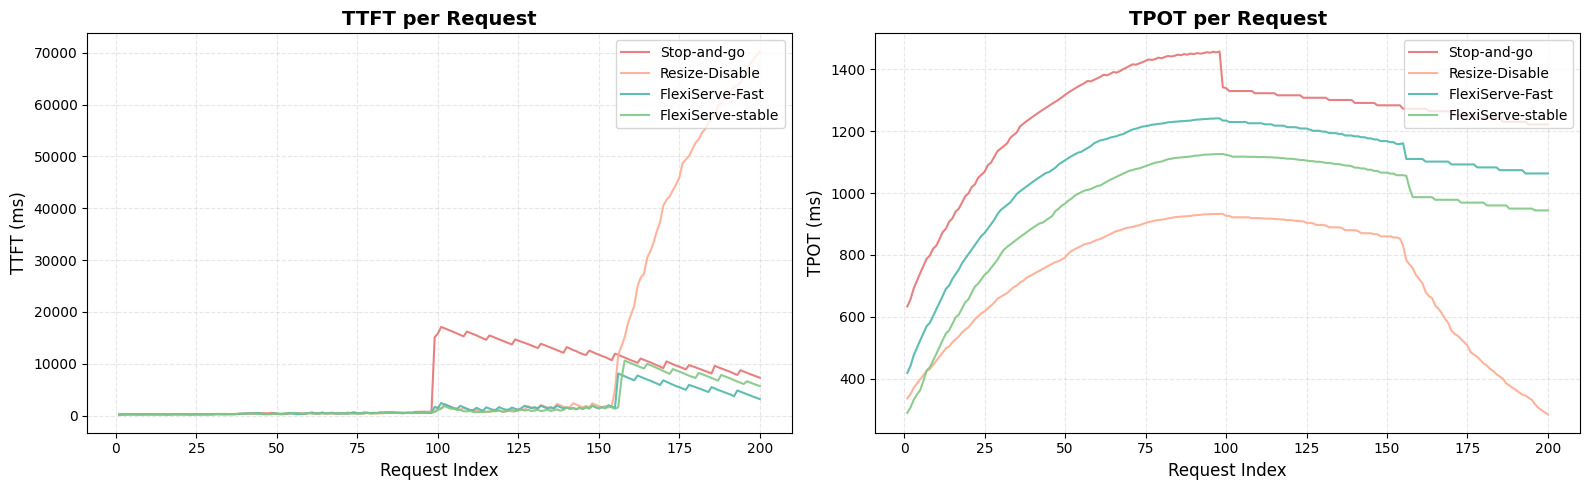

In [41]:
# Combined line chart: Both TTFT and TPOT side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Harmonious colors matching other charts
colors = {'Stop-and-go': '#E57373', 'Resize-Disable': '#FFAB91',
          'FlexiServe-Fast': '#4DB6AC', 'FlexiServe-stable': '#81C784'}
plot_order = ['Stop-and-go', 'Resize-Disable', 'FlexiServe-Fast', 'FlexiServe-stable']

# TTFT
ax1 = axes[0]
for name in plot_order:
    if name in data:
        df = data[name].sort_values('timestamp').reset_index(drop=True)
        df['request_idx'] = range(1, len(df) + 1)
        ax1.plot(df['request_idx'], df['ttfts'] * 1000, 
                 color=colors[name], linewidth=1.5, alpha=0.9, label=name)

ax1.set_xlabel('Request Index', fontsize=12)
ax1.set_ylabel('TTFT (ms)', fontsize=12)
ax1.set_title('TTFT per Request', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# TPOT
ax2 = axes[1]
for name in plot_order:
    if name in data:
        df = data[name].sort_values('timestamp').reset_index(drop=True)
        df['request_idx'] = range(1, len(df) + 1)
        ax2.plot(df['request_idx'], df['tpots'] * 1000, 
                 color=colors[name], linewidth=1.5, alpha=0.9, label=name)

ax2.set_xlabel('Request Index', fontsize=12)
ax2.set_ylabel('TPOT (ms)', fontsize=12)
ax2.set_title('TPOT per Request', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/e2e_combined_lines.png', dpi=150, bbox_inches='tight')
plt.show()

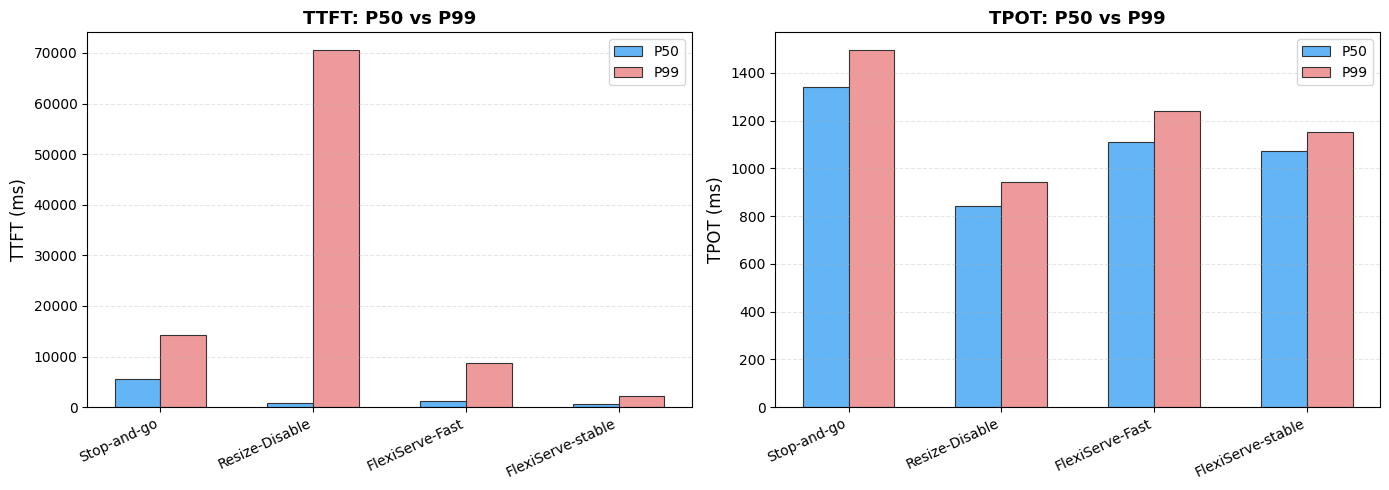


All figures saved to /home/bxb1/vllm_workbench/vllm/draws/


In [29]:
# P50 and P99 comparison with grouped bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_names = summary_df['Experiment'].tolist()
x = np.arange(len(exp_names))
width = 0.3  # Thinner bars

# Harmonious colors for P50/P99
p50_color = '#64B5F6'  # Light blue
p99_color = '#EF9A9A'  # Light red/coral

# TTFT P50 vs P99
ax1 = axes[0]
bars1_p50 = ax1.bar(x - width/2, summary_df['P50 TTFT (ms)'], width, label='P50', color=p50_color, edgecolor='#333', linewidth=0.8)
bars1_p99 = ax1.bar(x + width/2, summary_df['P99 TTFT (ms)'], width, label='P99', color=p99_color, edgecolor='#333', linewidth=0.8)
ax1.set_ylabel('TTFT (ms)', fontsize=12)
ax1.set_title('TTFT: P50 vs P99', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(exp_names, rotation=25, ha='right', fontsize=10)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# TPOT P50 vs P99
ax2 = axes[1]
bars2_p50 = ax2.bar(x - width/2, summary_df['P50 TPOT (ms)'], width, label='P50', color=p50_color, edgecolor='#333', linewidth=0.8)
bars2_p99 = ax2.bar(x + width/2, summary_df['P99 TPOT (ms)'], width, label='P99', color=p99_color, edgecolor='#333', linewidth=0.8)
ax2.set_ylabel('TPOT (ms)', fontsize=12)
ax2.set_title('TPOT: P50 vs P99', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(exp_names, rotation=25, ha='right', fontsize=10)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/e2e_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll figures saved to /home/bxb1/vllm_workbench/vllm/draws/")